# GPU-Optimized Pitch Detection System

This notebook implements a streamlined GPU-efficient pitch detection system using pose features and video features with sliding window analysis.

In [1]:
# Essential Imports and GPU Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json
from pathlib import Path
from tqdm import tqdm
import time
from scipy.ndimage import uniform_filter1d

# GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f}GB")
else:
    print("Using CPU - GPU not available")

print(f"Device: {device}")

GPU: NVIDIA GeForce RTX 5070 Ti
GPU Memory: 15.5GB
Device: cuda


# Core Model Architecture

In [2]:
class MultiModalBMN(nn.Module):
    """Multi-Modal Boundary Matching Network for pitch detection"""
    
    def __init__(self, pose_dim=68, video_dim=400, temporal_scale=100, hidden_dim=256):
        super().__init__()
        self.temporal_scale = temporal_scale
        self.hidden_dim = hidden_dim
        
        # Enhanced feature processing for better IoU performance
        self.pose_encoder = nn.Sequential(
            nn.Linear(pose_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),  # Slightly higher dropout for regularization
            nn.LayerNorm(hidden_dim)  # Use LayerNorm instead of BatchNorm1d
        )
        
        self.video_encoder = nn.Sequential(
            nn.Linear(video_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),  # Slightly higher dropout for regularization
            nn.LayerNorm(hidden_dim)  # Use LayerNorm instead of BatchNorm1d
        )
        
        # Temporal processing
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(hidden_dim * 2, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # Prediction heads
        self.frame_predictor = nn.Linear(hidden_dim, 1)
        self.start_predictor = nn.Linear(hidden_dim, 1)
        self.end_predictor = nn.Linear(hidden_dim, 1)
        
        # Attention for multi-modal fusion
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
            nn.Softmax(dim=-1)
        )
    
    def forward(self, pose_features, video_features):
        batch_size, seq_len = pose_features.shape[:2]
        
        # Encode features
        pose_encoded = self.pose_encoder(pose_features)
        video_encoded = self.video_encoder(video_features)
        
        # Multi-modal attention
        combined = torch.cat([pose_encoded, video_encoded], dim=-1)
        attention_weights = self.attention(combined)
        
        # Apply attention
        weighted_pose = pose_encoded * attention_weights[:, :, 0:1]
        weighted_video = video_encoded * attention_weights[:, :, 1:2]
        
        # Combine features
        fused_features = torch.cat([weighted_pose, weighted_video], dim=-1)
        
        # Temporal convolution (batch_size, seq_len, features) -> (batch_size, features, seq_len)
        temporal_input = fused_features.transpose(1, 2)
        temporal_output = self.temporal_conv(temporal_input)
        temporal_features = temporal_output.transpose(1, 2)
        
        # Predictions (return logits for training, apply sigmoid during inference)
        frame_logits = self.frame_predictor(temporal_features).squeeze(-1)
        start_logits = self.start_predictor(temporal_features).squeeze(-1)
        end_logits = self.end_predictor(temporal_features).squeeze(-1)
        
        # Apply sigmoid for inference (when not training)
        if not self.training:
            frame_predictions = torch.sigmoid(frame_logits)
            start_predictions = torch.sigmoid(start_logits)
            end_predictions = torch.sigmoid(end_logits)
        else:
            frame_predictions = frame_logits
            start_predictions = start_logits
            end_predictions = end_logits
        
        return {
            'frame_predictions': frame_predictions,
            'start_predictions': start_predictions,
            'end_predictions': end_predictions,
            'frame_logits': frame_logits,
            'start_logits': start_logits,
            'end_logits': end_logits,
            'temporal_features': temporal_features,

            'attention_weights': attention_weights,        }

In [3]:
class GPUSlidingWindowDataset(Dataset):
    """GPU-optimized sliding window dataset for pose and video features"""
    
    def __init__(self, pose_files, video_files, label_files, window_size=100, stride=50, fps=30):
        self.window_size = window_size
        self.stride = stride
        self.fps = fps
        
        # Load all data
        self.pose_data = []
        self.video_data = []
        self.labels = []
        
        for i, pose_file in enumerate(pose_files):
            # Load pose features with proper error handling
            with open(pose_file, 'r') as f:
                pose_json = json.load(f)
            
            # Process poses frame by frame to handle missing poses
            poses_list = []
            for frame in pose_json['poses']:
                if frame['poses'] and len(frame['poses']) > 0:
                    # Extract keypoints from first detected pose
                    keypoints = frame['poses'][0]['keypoints']
                    if len(keypoints) == 34:  # Ensure we have x,y for 17 joints
                        poses_list.append(keypoints)
                    else:
                        poses_list.append(np.zeros(34))  # Fallback for malformed data
                else:
                    poses_list.append(np.zeros(34))  # No pose detected
            
            # Convert to numpy array safely
            poses = np.array(poses_list)
            
            # Extend to 68 features (add confidence and visibility)
            extended_poses = np.zeros((poses.shape[0], 68))
            extended_poses[:, :34] = poses
            extended_poses[:, 34:51] = 0.8  # Default confidence for 17 joints
            extended_poses[:, 51:68] = 1.0  # Default visibility for 17 joints
            
            # Load video features
            video_features = np.load(video_files[i] if i < len(video_files) else video_files[0])
            
            # Load and parse labels correctly
            with open(label_files[i] if i < len(label_files) else label_files[0], 'r') as f:
                raw_labels = json.load(f)
            
            # Parse the label format correctly
            pitch_segments = []
            if isinstance(raw_labels, list) and len(raw_labels) > 0:
                # Handle the actual label format: [{"videoLabels": [{"ranges": [...]}]}]
                video_data = raw_labels[0]  # First video in the list
                if 'videoLabels' in video_data:
                    for label_group in video_data['videoLabels']:
                        if 'ranges' in label_group and 'timelinelabels' in label_group:
                            # Only process "Pitch" labels
                            if 'Pitch' in label_group['timelinelabels']:
                                for range_data in label_group['ranges']:
                                    pitch_segments.append({
                                        'start_frame': range_data['start'],
                                        'end_frame': range_data['end']
                                    })
            
            # Create standardized label format
            label_data = {'segments': pitch_segments}
            
            print(f"  Video {i+1}: Found {len(pitch_segments)} pitch segments")
            for j, seg in enumerate(pitch_segments):
                duration = (seg['end_frame'] - seg['start_frame']) / fps
                print(f"    Pitch {j+1}: frames {seg['start_frame']}-{seg['end_frame']} ({duration:.2f}s)")
            
            # Sync lengths and ensure minimum window size
            min_len = min(len(extended_poses), len(video_features))
            if min_len < window_size:
                print(f"Warning: Video {i} has only {min_len} frames, less than window size {window_size}")
                # Pad with zeros if too short
                pad_frames = window_size - min_len
                extended_poses = np.pad(extended_poses, ((0, pad_frames), (0, 0)), mode='constant')
                video_features = np.pad(video_features, ((0, pad_frames), (0, 0)), mode='constant')
                min_len = window_size
            
            extended_poses = extended_poses[:min_len]
            video_features = video_features[:min_len]
            
            self.pose_data.append(extended_poses)
            self.video_data.append(video_features)
            self.labels.append(label_data)
        
        # Create sliding windows
        self.windows = []
        for video_idx in range(len(self.pose_data)):
            num_frames = len(self.pose_data[video_idx])
            for start in range(0, max(1, num_frames - window_size + 1), stride):
                end = start + window_size
                if end <= num_frames:  # Ensure we don't exceed bounds
                    self.windows.append({
                        'video_idx': video_idx,
                        'start_frame': start,
                        'end_frame': end
                    })
        
        print(f"Dataset created: {len(self.windows)} windows from {len(pose_files)} videos")
        if len(self.windows) == 0:
            raise ValueError("No valid windows created. Check your data files and window size.")
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        window = self.windows[idx]
        video_idx = window['video_idx']
        start = window['start_frame']
        end = window['end_frame']
        
        # Extract window data
        pose_window = self.pose_data[video_idx][start:end]
        video_window = self.video_data[video_idx][start:end]
        
        # Ensure correct window size
        if len(pose_window) != self.window_size:
            # Pad if necessary
            pad_frames = self.window_size - len(pose_window)
            pose_window = np.pad(pose_window, ((0, pad_frames), (0, 0)), mode='constant')
            video_window = np.pad(video_window, ((0, pad_frames), (0, 0)), mode='constant')
        
        # Create frame labels based on pitch segments
        frame_labels = np.zeros(self.window_size)
        start_labels = np.zeros(self.window_size)
        end_labels = np.zeros(self.window_size)
        
        # Add pitch segments from labels
        if 'segments' in self.labels[video_idx]:
            for segment in self.labels[video_idx]['segments']:
                # Calculate overlap with current window
                seg_start = segment['start_frame']
                seg_end = segment['end_frame']
                
                # Find intersection with current window
                window_seg_start = max(0, seg_start - start)
                window_seg_end = min(self.window_size, seg_end - start)
                
                # Only add if there's actual overlap
                if window_seg_start < self.window_size and window_seg_end > 0:
                    # Ensure we don't go out of bounds
                    window_seg_start = max(0, window_seg_start)
                    window_seg_end = min(self.window_size, window_seg_end)
                    
                    # Mark frames as pitch
                    frame_labels[window_seg_start:window_seg_end] = 1.0
                    
                    # Mark start boundary
                    if window_seg_start < self.window_size:
                        start_labels[window_seg_start] = 1.0
                    
                    # Mark end boundary  
                    if window_seg_end > 0 and window_seg_end <= self.window_size:
                        end_labels[window_seg_end-1] = 1.0
        
        return {
            'pose_features': torch.FloatTensor(pose_window),
            'video_features': torch.FloatTensor(video_window),
            'frame_labels': torch.FloatTensor(frame_labels),
            'start_boundary_labels': torch.FloatTensor(start_labels),
            'end_boundary_labels': torch.FloatTensor(end_labels),
            'window_info': window
        }

def create_dataloader(dataset, batch_size=32, num_workers=2):
    """Create optimized dataloader"""
    return DataLoader(
        dataset, 
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

# GPU Training Function

In [4]:
# IoU and Pitch Detection Metrics
def calculate_segment_iou(pred_start, pred_end, true_start, true_end):
    """Calculate Intersection over Union for two segments"""
    intersection_start = max(pred_start, true_start)
    intersection_end = min(pred_end, true_end)
    
    if intersection_start >= intersection_end:
        return 0.0
    
    intersection = intersection_end - intersection_start
    union = (pred_end - pred_start) + (true_end - true_start) - intersection
    
    return intersection / union if union > 0 else 0.0

def extract_segments_from_predictions(predictions, threshold=0.5, min_duration=10):
    """Extract pitch segments from frame-level predictions with improved post-processing"""
    segments = []
    in_pitch = False
    start_frame = 0
    
    # Apply smoothing to reduce noise
    if len(predictions) > 5:
        from scipy.ndimage import uniform_filter1d
        smoothed = uniform_filter1d(predictions, size=3)
    else:
        smoothed = predictions
    
    # Use adaptive threshold if predictions are generally low
    pred_max = np.max(smoothed)
    pred_mean = np.mean(smoothed)
    
    if pred_max < 0.3:  # If all predictions are low, use adaptive threshold
        adaptive_threshold = pred_mean + 0.5 * (pred_max - pred_mean)
        threshold = min(threshold, adaptive_threshold)
    
    for frame_idx, confidence in enumerate(smoothed):
        if confidence > threshold and not in_pitch:
            in_pitch = True
            start_frame = frame_idx
        elif confidence <= threshold and in_pitch:
            in_pitch = False
            duration = frame_idx - start_frame
            if duration >= min_duration:  # Filter out very short segments
                segments.append((start_frame, frame_idx))
    
    # Handle pitch continuing to end
    if in_pitch:
        duration = len(smoothed) - start_frame
        if duration >= min_duration:
            segments.append((start_frame, len(smoothed)))
    
    return segments

def calculate_iou_loss(predictions, targets, smooth=1e-6):
    """Calculate IoU loss for better segmentation performance"""
    # Flatten tensors
    predictions = predictions.view(-1)
    targets = targets.view(-1)
    
    # Calculate intersection and union
    intersection = (predictions * targets).sum()
    union = predictions.sum() + targets.sum() - intersection
    
    # Calculate IoU
    iou = (intersection + smooth) / (union + smooth)
    
    # Return 1 - IoU as loss (we want to minimize this)
    return 1 - iou

def calculate_dice_loss(predictions, targets, smooth=1e-6):
    """Calculate Dice loss as alternative to IoU"""
    # Flatten tensors
    predictions = predictions.view(-1)
    targets = targets.view(-1)
    
    # Calculate intersection
    intersection = (predictions * targets).sum()
    
    # Calculate Dice coefficient
    dice = (2. * intersection + smooth) / (predictions.sum() + targets.sum() + smooth)
    
    # Return 1 - Dice as loss
    return 1 - dice

def segment_aware_loss(frame_preds, frame_targets, start_preds, start_targets, end_preds, end_targets):
    """Enhanced IoU-focused loss that handles class imbalance better"""
    batch_size = frame_preds.size(0)
    
    total_iou_loss = 0
    total_focal_loss = 0
    total_segment_loss = 0
    
    for b in range(batch_size):
        # Enhanced IoU loss with smoothing for empty predictions
        frame_probs = torch.sigmoid(frame_preds[b])
        targets = frame_targets[b]
        
        # Calculate IoU with better handling of edge cases
        intersection = (frame_probs * targets).sum()
        union = frame_probs.sum() + targets.sum() - intersection
        
        # Add smoothing and handle empty predictions better
        smooth = 1e-6
        iou = (intersection + smooth) / (union + smooth)
        
        # Enhanced IoU loss that penalizes poor overlap more heavily
        iou_loss = 1 - iou
        if union < 1e-3:  # Handle cases with no predictions or targets
            iou_loss = torch.tensor(1.0).to(frame_preds.device)
        
        total_iou_loss += iou_loss
        
        # Add focal loss to handle class imbalance better
        alpha = 0.75  # Weight for positive class
        gamma = 2.0   # Focusing parameter
        
        bce = nn.functional.binary_cross_entropy_with_logits(frame_preds[b], targets, reduction='none')
        pt = torch.exp(-bce)
        focal_loss = alpha * (1 - pt) ** gamma * bce
        total_focal_loss += focal_loss.mean()
        
        # Simplified boundary loss - only if we have boundaries
        if start_targets[b].sum() > 0 or end_targets[b].sum() > 0:
            start_loss = nn.functional.binary_cross_entropy_with_logits(
                start_preds[b], start_targets[b], 
                pos_weight=torch.tensor(10.0).to(frame_preds.device)
            )
            end_loss = nn.functional.binary_cross_entropy_with_logits(
                end_preds[b], end_targets[b],
                pos_weight=torch.tensor(10.0).to(frame_preds.device)
            )
            total_segment_loss += (start_loss + end_loss)
    
    # Combine losses with strong focus on IoU
    avg_iou_loss = total_iou_loss / batch_size
    avg_focal_loss = total_focal_loss / batch_size
    avg_segment_loss = total_segment_loss / batch_size if total_segment_loss > 0 else 0
    
    # Weight heavily toward IoU optimization with focal loss support
    return 0.7 * avg_iou_loss + 0.2 * avg_focal_loss + 0.1 * avg_segment_loss

def evaluate_pitch_detection(predicted_segments, true_segments, iou_threshold=0.3):
    """Evaluate pitch detection using IoU-based metrics"""
    if len(true_segments) == 0:
        return {
            'precision': 1.0 if len(predicted_segments) == 0 else 0.0,
            'recall': 1.0,
            'f1': 1.0 if len(predicted_segments) == 0 else 0.0,
            'mean_iou': 0.0,
            'matched_segments': 0,
            'total_predicted': len(predicted_segments),
            'total_true': len(true_segments)
        }
    
    if len(predicted_segments) == 0:
        return {
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
            'mean_iou': 0.0,
            'matched_segments': 0,
            'total_predicted': len(predicted_segments),
            'total_true': len(true_segments)
        }
    
    # Match predicted segments to true segments using IoU
    matched_pred = set()
    matched_true = set()
    ious = []
    
    for i, (pred_start, pred_end) in enumerate(predicted_segments):
        best_iou = 0.0
        best_match = -1
        
        for j, (true_start, true_end) in enumerate(true_segments):
            if j in matched_true:
                continue
                
            iou = calculate_segment_iou(pred_start, pred_end, true_start, true_end)
            if iou > best_iou and iou >= iou_threshold:
                best_iou = iou
                best_match = j
        
        if best_match >= 0:
            matched_pred.add(i)
            matched_true.add(best_match)
            ious.append(best_iou)
    
    # Calculate metrics
    precision = len(matched_pred) / len(predicted_segments)
    recall = len(matched_true) / len(true_segments)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    mean_iou = np.mean(ious) if ious else 0.0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou': mean_iou,
        'matched_segments': len(matched_pred),
        'total_predicted': len(predicted_segments),
        'total_true': len(true_segments)
    }

def analyze_dataset_distribution(dataset):
    """Analyze pitch vs non-pitch distribution in the dataset"""
    total_frames = 0
    pitch_frames = 0
    pitch_segments = 0
    non_pitch_segments = 0
    
    print("📊 Analyzing dataset distribution...")
    
    for i in range(len(dataset)):
        sample = dataset[i]
        frame_labels = sample['frame_labels'].numpy()
        
        total_frames += len(frame_labels)
        pitch_frames += np.sum(frame_labels)
        
        # Count segments in this window
        segments = extract_segments_from_predictions(frame_labels, threshold=0.5, min_duration=1)
        pitch_segments += len(segments)
        
        # Count non-pitch segments (gaps between pitches)
        if len(segments) > 0:
            # Count gaps between segments and at beginning/end
            prev_end = 0
            for start, end in segments:
                if start > prev_end:
                    non_pitch_segments += 1
                prev_end = end
            if prev_end < len(frame_labels):
                non_pitch_segments += 1
        else:
            non_pitch_segments += 1
    
    pitch_ratio = pitch_frames / total_frames if total_frames > 0 else 0
    
    print(f"  Total frames: {total_frames:,}")
    print(f"  Pitch frames: {pitch_frames:,} ({pitch_ratio:.1%})")
    print(f"  Non-pitch frames: {total_frames - pitch_frames:,} ({1-pitch_ratio:.1%})")
    print(f"  Pitch segments: {pitch_segments}")
    print(f"  Non-pitch segments: {non_pitch_segments}")
    print(f"  Avg frames per pitch segment: {pitch_frames/pitch_segments:.1f}" if pitch_segments > 0 else "  No pitch segments found")
    print("-" * 50)
    
    return {
        'total_frames': total_frames,
        'pitch_frames': pitch_frames,
        'non_pitch_frames': total_frames - pitch_frames,
        'pitch_segments': pitch_segments,
        'non_pitch_segments': non_pitch_segments,
        'pitch_ratio': pitch_ratio
    }

In [5]:
def train_pitch_detector(pose_files, video_files, label_files, num_epochs=10, batch_size=32, lr=0.001, save_best=True, checkpoint_dir="./checkpoints"):
    """Train the pitch detection model with IoU-optimized loss function and best model saving"""
    
    # Create checkpoint directory if it doesn't exist
    if save_best:
        import os
        os.makedirs(checkpoint_dir, exist_ok=True)
        print(f"📁 Checkpoint directory: {checkpoint_dir}")
    
    # Create dataset and dataloader
    dataset = GPUSlidingWindowDataset(pose_files, video_files, label_files)
    dataloader = create_dataloader(dataset, batch_size=batch_size)
    
    # Analyze dataset distribution before training
    dataset_stats = analyze_dataset_distribution(dataset)
    
    # Enhanced class weight calculation for better IoU performance
    pitch_ratio = dataset_stats['pitch_ratio']
    if pitch_ratio > 0:
        # More aggressive weighting for severe imbalance
        if pitch_ratio < 0.05:  # <5% pitch frames
            pos_weight = min(50.0, (1 - pitch_ratio) / pitch_ratio)  # Cap very high weights
            print(f"   SEVERE imbalance: {pitch_ratio:.1%} pitch frames")
        elif pitch_ratio < 0.15:  # <15% pitch frames  
            pos_weight = min(20.0, (1 - pitch_ratio) / pitch_ratio)
            print(f"   HIGH imbalance: {pitch_ratio:.1%} pitch frames")
        else:
            pos_weight = (1 - pitch_ratio) / pitch_ratio
            print(f"   Moderate imbalance: {pitch_ratio:.1%} pitch frames")
        
        print(f"   Using enhanced positive class weight: {pos_weight:.2f}")
        print(f"   Expected to improve IoU by better minority class learning")
    else:
        pos_weight = 1.0
        print("   No pitch frames found in dataset!")
        return None, None
    
    # Initialize fresh model with correct dimensions
    # Clear any cached models to avoid dimension conflicts
    if 'model' in globals():
        del globals()['model']
    torch.cuda.empty_cache()  # Clear GPU memory
    
    # Create new model instance
    model = MultiModalBMN(hidden_dim=256).to(device)
    print(f"   Model initialized with hidden_dim=256")
    
    # Use different optimizers and loss functions for better learning
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)  # More aggressive LR decay
    
    # Training history with IoU tracking
    history = {
        'loss': [], 'iou_loss': [], 'precision': [], 'recall': [], 'f1': [], 'mean_iou': []
    }
    
    print(f"🚀 Starting IoU-optimized training with {num_epochs} epochs...")
    print(f"   Batch size: {batch_size}")
    print(f"   Learning rate: {lr}")
    print(f"   Total windows: {len(dataset)}")
    print(f"   Focus: Maximizing mean IoU performance")
    
    # Training loop with IoU-focused loss
    model.train()
    best_iou = 0.0
    best_model_path = None
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        epoch_iou_loss = 0
        all_predictions = []
        all_true_segments = []
        
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch_idx, batch in enumerate(progress_bar):
            # Move to GPU
            pose_features = batch['pose_features'].to(device)
            video_features = batch['video_features'].to(device)
            frame_labels = batch['frame_labels'].to(device)
            start_labels = batch['start_boundary_labels'].to(device)
            end_labels = batch['end_boundary_labels'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(pose_features, video_features)
            
            # Use logits directly from model output for loss calculation
            frame_logits = outputs['frame_logits']
            start_logits = outputs['start_logits']
            end_logits = outputs['end_logits']
            
            # Use IoU-optimized loss function
            total_loss = segment_aware_loss(
                frame_logits, frame_labels,
                start_logits, start_labels,
                end_logits, end_labels
            )
            
            # Calculate pure IoU loss for tracking
            batch_iou_loss = 0
            for i in range(frame_logits.size(0)):
                iou_loss = calculate_iou_loss(torch.sigmoid(frame_logits[i]), frame_labels[i])
                batch_iou_loss += iou_loss
            batch_iou_loss /= frame_logits.size(0)
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_iou_loss += batch_iou_loss.item()
            
            # Collect predictions for IoU evaluation
            if len(all_predictions) < 100:  # More samples for better evaluation
                with torch.no_grad():
                    batch_preds = torch.sigmoid(frame_logits).cpu().numpy()
                    batch_labels = frame_labels.cpu().numpy()
                    
                    # Enhanced adaptive threshold for better IoU
                    for i in range(min(5, len(batch_preds))):  # More samples for better stats
                        pred_mean = np.mean(batch_preds[i])
                        pred_std = np.std(batch_preds[i])
                        pred_max = np.max(batch_preds[i])
                        
                        # Smarter threshold that considers prediction distribution
                        if pred_max < 0.1:  # Very low predictions
                            adaptive_threshold = max(0.05, pred_mean + 2 * pred_std)
                        elif pred_std < 0.01:  # Very uniform predictions
                            adaptive_threshold = max(0.1, pred_mean + pred_std)
                        else:  # Normal case - optimize for IoU
                            adaptive_threshold = min(0.4, max(0.15, pred_mean + 0.5 * pred_std))
                        
                        # More conservative threshold to improve precision and IoU
                        pred_segments = extract_segments_from_predictions(
                            batch_preds[i], threshold=adaptive_threshold, min_duration=3
                        )
                        true_segments = extract_segments_from_predictions(
                            batch_labels[i], threshold=0.5, min_duration=1
                        )
                        
                        all_predictions.append(pred_segments)
                        all_true_segments.append(true_segments)
            
            # Show prediction statistics with IoU focus
            if batch_idx % 50 == 0:
                with torch.no_grad():
                    pred_probs = torch.sigmoid(frame_logits)
                    mean_pred = pred_probs.mean().item()
                    max_pred = pred_probs.max().item()
                    min_pred = pred_probs.min().item()
                    progress_bar.set_postfix({
                        'Loss': f"{total_loss.item():.4f}",
                        'IoU_Loss': f"{batch_iou_loss.item():.4f}",
                        'Pred': f"{mean_pred:.3f}({min_pred:.3f}-{max_pred:.3f})"
                    })
        
        # Calculate epoch metrics with focus on IoU
        avg_loss = epoch_loss / len(dataloader)
        avg_iou_loss = epoch_iou_loss / len(dataloader)
        
        # Evaluate with IoU-optimized criteria
        total_precision = 0
        total_recall = 0
        total_f1 = 0
        total_iou = 0
        valid_samples = 0
        
        for pred_segs, true_segs in zip(all_predictions, all_true_segments):
            # Use stricter IoU threshold for evaluation (focusing on quality)
            metrics = evaluate_pitch_detection(pred_segs, true_segs, iou_threshold=0.3)
            if len(pred_segs) > 0 or len(true_segs) > 0:
                total_precision += metrics['precision']
                total_recall += metrics['recall']
                total_f1 += metrics['f1']
                total_iou += metrics['mean_iou']
                valid_samples += 1
        
        if valid_samples > 0:
            avg_precision = total_precision / valid_samples
            avg_recall = total_recall / valid_samples
            avg_f1 = total_f1 / valid_samples
            avg_mean_iou = total_iou / valid_samples
        else:
            avg_precision = avg_recall = avg_f1 = avg_mean_iou = 0.0
        
        # Store metrics with IoU tracking
        history['loss'].append(avg_loss)
        history['iou_loss'].append(avg_iou_loss)
        history['precision'].append(avg_precision)
        history['recall'].append(avg_recall)
        history['f1'].append(avg_f1)
        history['mean_iou'].append(avg_mean_iou)
        
        # Track best IoU for model selection and save best model
        if avg_mean_iou > best_iou:
            best_iou = avg_mean_iou
            print(f"   🎯 New best IoU: {best_iou:.4f}")
            
            # Save the best model checkpoint
            if save_best:
                import datetime
                timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
                best_model_path = os.path.join(checkpoint_dir, f"best_model_iou_{best_iou:.4f}_epoch_{epoch+1}_{timestamp}.pth")
                
                checkpoint = {
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'epoch': epoch + 1,
                    'best_iou': best_iou,
                    'history': history,
                    'hyperparameters': {
                        'num_epochs': num_epochs,
                        'batch_size': batch_size,
                        'lr': lr,
                        'hidden_dim': 256
                    },
                    'dataset_stats': dataset_stats,
                    'training_files': {
                        'pose_files': pose_files,
                        'video_files': video_files,
                        'label_files': label_files
                    }
                }
                
                torch.save(checkpoint, best_model_path)
                print(f"   💾 Saved best model: {os.path.basename(best_model_path)}")
        
        # Update learning rate
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        
        # Print epoch summary with IoU emphasis
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Total Loss: {avg_loss:.4f} | IoU Loss: {avg_iou_loss:.4f} | LR: {current_lr:.6f}")
        print(f"  Precision: {avg_precision:.3f} | Recall: {avg_recall:.3f} | F1: {avg_f1:.3f}")
        print(f"  🎯 Mean IoU: {avg_mean_iou:.4f} | Best IoU: {best_iou:.4f}")
        
        # Early stopping based on IoU plateau
        if epoch > 3 and len(history['mean_iou']) > 3:
            recent_ious = history['mean_iou'][-3:]
            if all(abs(recent_ious[i] - recent_ious[i-1]) < 0.001 for i in range(1, len(recent_ious))):
                print(f"   IoU plateaued - consider stopping or adjusting hyperparameters")
    
    print("✅ IoU-optimized training completed!")
    print(f"🏆 Final best IoU: {best_iou:.4f}")
    
    if save_best and best_model_path:
        print(f"💾 Best model saved to: {best_model_path}")
        print(f"   You can load this model later using: torch.load('{best_model_path}')")
    
    return model, history, best_model_path

In [10]:
def load_best_model(checkpoint_path, device='cuda'):
    """
    Load the best saved model from checkpoint
    
    Args:
        checkpoint_path: Path to the saved checkpoint file
        device: Device to load the model on ('cuda' or 'cpu')
    
    Returns:
        model: Loaded model in evaluation mode
        checkpoint_info: Dictionary with training information
    """
    print(f"📂 Loading model checkpoint from: {checkpoint_path}")
    
    # Load checkpoint with weights_only=False for compatibility with numpy objects
    # This is safe since we trust our own checkpoint files
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Create model with same architecture
    hidden_dim = checkpoint['hyperparameters'].get('hidden_dim', 256)
    model = MultiModalBMN(hidden_dim=hidden_dim).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Extract useful information
    checkpoint_info = {
        'epoch': checkpoint['epoch'],
        'best_iou': checkpoint['best_iou'],
        'hyperparameters': checkpoint['hyperparameters'],
        'dataset_stats': checkpoint.get('dataset_stats', {}),
        'training_files': checkpoint.get('training_files', {}),
        'final_metrics': {
            'final_loss': checkpoint['history']['loss'][-1] if checkpoint['history']['loss'] else None,
            'final_precision': checkpoint['history']['precision'][-1] if checkpoint['history']['precision'] else None,
            'final_recall': checkpoint['history']['recall'][-1] if checkpoint['history']['recall'] else None,
            'final_f1': checkpoint['history']['f1'][-1] if checkpoint['history']['f1'] else None,
            'final_iou': checkpoint['history']['mean_iou'][-1] if checkpoint['history']['mean_iou'] else None
        }
    }
    
    print(f"✅ Model loaded successfully!")
    print(f"   📊 Best IoU achieved: {checkpoint_info['best_iou']:.4f}")
    print(f"   📈 Trained for {checkpoint_info['epoch']} epochs")
    print(f"   🎯 Final metrics:")
    print(f"      IoU: {checkpoint_info['final_metrics']['final_iou']:.4f}")
    print(f"      F1: {checkpoint_info['final_metrics']['final_f1']:.4f}")
    print(f"      Precision: {checkpoint_info['final_metrics']['final_precision']:.4f}")
    print(f"      Recall: {checkpoint_info['final_metrics']['final_recall']:.4f}")
    
    return model, checkpoint_info


def find_best_checkpoint(checkpoint_dir="./checkpoints"):
    """
    Find the checkpoint with the highest IoU in the checkpoint directory
    
    Args:
        checkpoint_dir: Directory to search for checkpoints
    
    Returns:
        best_checkpoint_path: Path to the best checkpoint, or None if no checkpoints found
    """
    import os
    import glob
    
    if not os.path.exists(checkpoint_dir):
        print(f"❌ Checkpoint directory does not exist: {checkpoint_dir}")
        return None
    
    # Find all checkpoint files
    checkpoint_pattern = os.path.join(checkpoint_dir, "best_model_iou_*.pth")
    checkpoint_files = glob.glob(checkpoint_pattern)
    
    if not checkpoint_files:
        print(f"❌ No checkpoints found in {checkpoint_dir}")
        return None
    
    # Extract IoU values from filenames and find the best one
    best_iou = 0.0
    best_checkpoint = None
    
    for checkpoint_file in checkpoint_files:
        try:
            # Extract IoU from filename: best_model_iou_0.1234_epoch_...
            filename = os.path.basename(checkpoint_file)
            iou_start = filename.find("iou_") + 4
            iou_end = filename.find("_epoch_")
            iou_value = float(filename[iou_start:iou_end])
            
            if iou_value > best_iou:
                best_iou = iou_value
                best_checkpoint = checkpoint_file
                
        except (ValueError, IndexError):
            print(f"⚠️ Could not parse IoU from filename: {filename}")
            continue
    
    if best_checkpoint:
        print(f"🏆 Found best checkpoint: IoU = {best_iou:.4f}")
        print(f"📁 Path: {best_checkpoint}")
    else:
        print(f"❌ Could not determine best checkpoint")
    
    return best_checkpoint

In [7]:
def predict_pitch_timestamps(model, pose_file, video_file, window_size=100, stride=50, fps=30, threshold=0.5):
    """Predict pitch start and end timestamps from pose and video features"""
    
    # Load pose data with proper error handling
    with open(pose_file, 'r') as f:
        pose_json = json.load(f)
    
    # Process poses frame by frame to handle missing poses
    poses_list = []
    for frame in pose_json['poses']:
        if frame['poses'] and len(frame['poses']) > 0:
            # Extract keypoints from first detected pose
            keypoints = frame['poses'][0]['keypoints']
            if len(keypoints) == 34:  # Ensure we have x,y for 17 joints
                poses_list.append(keypoints)
            else:
                poses_list.append(np.zeros(34))  # Fallback for malformed data
        else:
            poses_list.append(np.zeros(34))  # No pose detected
    
    # Convert to numpy array safely
    poses = np.array(poses_list)
    
    # Extend to 68 features
    extended_poses = np.zeros((poses.shape[0], 68))
    extended_poses[:, :34] = poses
    extended_poses[:, 34:51] = 0.8  # Default confidence
    extended_poses[:, 51:68] = 1.0  # Default visibility
    
    video_features = np.load(video_file)
    
    # Sync lengths
    min_len = min(len(extended_poses), len(video_features))
    extended_poses = extended_poses[:min_len]
    video_features = video_features[:min_len]
    
    print(f"Processing {min_len} frames for prediction...")
    
    # Create sliding windows for prediction
    model.eval()
    predictions = np.zeros(min_len)
    window_counts = np.zeros(min_len)  # Track overlapping windows
    
    with torch.no_grad():
        for start in range(0, max(1, min_len - window_size + 1), stride):
            end = min(start + window_size, min_len)
            actual_window_size = end - start
            
            # Skip if window is too small
            if actual_window_size < window_size // 2:
                continue
                
            # Pad window if needed
            pose_window = extended_poses[start:end]
            video_window = video_features[start:end]
            
            if actual_window_size < window_size:
                pad_size = window_size - actual_window_size
                pose_window = np.pad(pose_window, ((0, pad_size), (0, 0)), mode='constant')
                video_window = np.pad(video_window, ((0, pad_size), (0, 0)), mode='constant')
            
            pose_tensor = torch.FloatTensor(pose_window).unsqueeze(0).to(device)
            video_tensor = torch.FloatTensor(video_window).unsqueeze(0).to(device)
            
            outputs = model(pose_tensor, video_tensor)
            frame_preds = outputs['frame_predictions'].cpu().numpy()[0]
            
            # Only use predictions for actual frames (not padded ones)
            valid_preds = frame_preds[:actual_window_size]
            predictions[start:end] += valid_preds
            window_counts[start:end] += 1
    
    # Average overlapping predictions
    mask = window_counts > 0
    predictions[mask] = predictions[mask] / window_counts[mask]
    
    # Apply smoothing to reduce noise
    if len(predictions) > 5:
        from scipy.ndimage import uniform_filter1d
        smoothed_predictions = uniform_filter1d(predictions, size=5)
    else:
        smoothed_predictions = predictions
    
    # Debug: Print prediction statistics
    print(f"Raw prediction stats: min={np.min(predictions):.6f}, max={np.max(predictions):.6f}, mean={np.mean(predictions):.6f}")
    print(f"Smoothed prediction stats: min={np.min(smoothed_predictions):.6f}, max={np.max(smoothed_predictions):.6f}, mean={np.mean(smoothed_predictions):.6f}")
    
    # Check if predictions are meaningful
    pred_max = np.max(smoothed_predictions)
    pred_mean = np.mean(smoothed_predictions)
    pred_std = np.std(smoothed_predictions)
    
    print(f"Prediction analysis: max={pred_max:.6f}, mean={pred_mean:.6f}, std={pred_std:.6f}")
    
    # If all predictions are essentially zero or very low, return empty results
    if pred_max < 0.001 or pred_std < 0.001:
        print(f"⚠️ Model predictions are too low or uniform (max={pred_max:.6f}, std={pred_std:.6f})")
        print("This suggests the model hasn't learned to distinguish pitch vs non-pitch frames.")
        print("Consider:")
        print("  1. Training for more epochs")
        print("  2. Adjusting learning rate or loss function")
        print("  3. Checking if training data has proper labels")
        return [], predictions
    
    # Adaptive threshold based on prediction distribution
    if pred_max < 0.4:
        adaptive_threshold = pred_mean + 1.0 * pred_std  # More conservative
        threshold = min(threshold, max(0.05, adaptive_threshold))
        print(f"Using adaptive threshold: {threshold:.6f} (max pred: {pred_max:.6f})")
    else:
        print(f"Using original threshold: {threshold:.6f}")
    
    # Enhanced pitch segment detection optimized for IoU
    pitch_segments = []
    in_pitch = False
    start_frame = 0
    min_pitch_duration = max(5, int(0.3 * fps))  # Shorter minimum duration for better recall
    
    # Use hysteresis thresholding for better IoU
    high_threshold = threshold
    low_threshold = threshold * 0.7  # Lower threshold for continuing segments
    
    for frame_idx, confidence in enumerate(smoothed_predictions):
        if confidence > high_threshold and not in_pitch:
            # Start of pitch with high threshold
            in_pitch = True
            start_frame = frame_idx
        elif confidence <= low_threshold and in_pitch:
            # End of pitch with low threshold (hysteresis)
            in_pitch = False
            duration_frames = frame_idx - start_frame
            
            if duration_frames >= min_pitch_duration:
                start_time = start_frame / fps
                end_time = frame_idx / fps
                avg_confidence = np.mean(smoothed_predictions[start_frame:frame_idx])
                
                # Only keep segments with reasonable confidence for better precision
                if avg_confidence > threshold * 0.8:
                    pitch_segments.append({
                        'start_frame': start_frame,
                        'end_frame': frame_idx,
                        'start_time': start_time,
                        'end_time': end_time,
                        'duration': end_time - start_time,
                        'confidence': avg_confidence
                    })
    
    # Handle case where pitch continues to end of video (but only if meaningful)
    if in_pitch and pred_max > 0.05:  # Only if we have some meaningful predictions
        duration_frames = len(smoothed_predictions) - start_frame
        if duration_frames >= min_pitch_duration:
            start_time = start_frame / fps
            end_time = len(smoothed_predictions) / fps
            avg_confidence = np.mean(smoothed_predictions[start_frame:])
            
            pitch_segments.append({
                'start_frame': start_frame,
                'end_frame': len(smoothed_predictions),
                'start_time': start_time,
                'end_time': end_time,
                'duration': end_time - start_time,
                'confidence': avg_confidence
            })
    
    print(f"Found {len(pitch_segments)} pitch segments with improved logic")
    return pitch_segments, predictions

In [8]:
def evaluate_model_performance(model, pose_file, video_file, label_file, fps=30, threshold=0.3):
    """Comprehensive evaluation of model performance with IoU metrics"""
    
    # Make predictions
    pitch_segments, frame_predictions = predict_pitch_timestamps(
        model, pose_file, video_file, fps=fps, threshold=threshold
    )
    
    # Load and parse ground truth labels
    with open(label_file, 'r') as f:
        raw_labels = json.load(f)
    
    # Parse the label format correctly
    true_segments = []
    if isinstance(raw_labels, list) and len(raw_labels) > 0:
        # Handle the actual label format: [{"videoLabels": [{"ranges": [...]}]}]
        video_data = raw_labels[0]  # First video in the list
        if 'videoLabels' in video_data:
            for label_group in video_data['videoLabels']:
                if 'ranges' in label_group and 'timelinelabels' in label_group:
                    # Only process "Pitch" labels
                    if 'Pitch' in label_group['timelinelabels']:
                        for range_data in label_group['ranges']:
                            true_segments.append((range_data['start'], range_data['end']))
    
    print(f"Ground truth: {len(true_segments)} pitch segments")
    for i, (start, end) in enumerate(true_segments):
        duration = (end - start) / fps
        print(f"  True Pitch {i+1}: frames {start}-{end} ({duration:.2f}s)")
    
    # Convert predicted segments to frame-based
    pred_segments = [(seg['start_frame'], seg['end_frame']) for seg in pitch_segments]
    
    # Calculate IoU-based metrics
    metrics = evaluate_pitch_detection(pred_segments, true_segments)
    
    # Calculate timing accuracy for matched segments
    timing_errors = []
    if len(pitch_segments) > 0 and len(true_segments) > 0:
        for pred_seg in pitch_segments:
            best_iou = 0
            best_match = None
            for i, (true_start, true_end) in enumerate(true_segments):
                iou = calculate_segment_iou(
                    pred_seg['start_frame'], pred_seg['end_frame'],
                    true_start, true_end
                )
                if iou > best_iou:
                    best_iou = iou
                    best_match = (true_start, true_end)
            
            if best_match and best_iou > 0.3:
                start_error = abs(pred_seg['start_frame'] - best_match[0]) / fps
                end_error = abs(pred_seg['end_frame'] - best_match[1]) / fps
                timing_errors.append({'start_error': start_error, 'end_error': end_error})
    
    return {
        'segments': pitch_segments,
        'metrics': metrics,
        'timing_errors': timing_errors,
        'frame_predictions': frame_predictions
    }

# Example Usage

In [13]:
# File paths
pose_files = ["pose_features/tennessee_alabama_sr_gm1_pose_features_20251123_092841.json"]
video_files = ["video_features/tennessee_alabama_sr_gm1_raw_video_features_20251123_123352.npy"]
label_files = ["../Data/labels/example.json"]

In [14]:


# Enhanced training with better IoU optimization based on dataset analysis
print("🎯 Training Enhanced IoU-optimized pitch detection model...")
print("Focus: Maximizing mean IoU with improved class imbalance handling")

# Use parameters optimized for the severe class imbalance we detected
model, history, best_model_path = train_pitch_detector(
    pose_files=pose_files,
    video_files=video_files, 
    label_files=label_files,
    num_epochs=120,  # Sufficient epochs for convergence
    batch_size=16,  # Larger batch for more stable gradients with imbalanced data
    lr=0.001,      # Lower learning rate for more stable training with class imbalance
    save_best=True,  # Enable saving the best model based on IoU
    checkpoint_dir="./checkpoints"  # Directory to save checkpoints
)

print("✅ Enhanced IoU-optimized training completed!")

# Display IoU training progress
if history:
    print(f"\n📈 Enhanced IoU Training Progress:")
    print(f"  Initial IoU: {history['mean_iou'][0]:.4f}")
    print(f"  Final IoU: {history['mean_iou'][-1]:.4f}")
    print(f"  Best IoU: {max(history['mean_iou']):.4f}")
    print(f"  IoU Improvement: {history['mean_iou'][-1] - history['mean_iou'][0]:+.4f}")
    
    # Show IoU progress over epochs
    print(f"\n📊 IoU Progress by Epoch:")
    for i in range(0, len(history['mean_iou']), max(1, len(history['mean_iou'])//10)):
        print(f"    Epoch {i+1}: IoU = {history['mean_iou'][i]:.4f}")
    
    # Check for improvement trends
    if len(history['mean_iou']) > 5:
        early_iou = np.mean(history['mean_iou'][:5])
        late_iou = np.mean(history['mean_iou'][-5:])
        trend = "↗️ Improving" if late_iou > early_iou else "↘️ Declining" if late_iou < early_iou else "→ Stable"
        print(f"  Training Trend: {trend} (Early: {early_iou:.4f} → Late: {late_iou:.4f})")

🎯 Training Enhanced IoU-optimized pitch detection model...
Focus: Maximizing mean IoU with improved class imbalance handling
📁 Checkpoint directory: ./checkpoints


KeyboardInterrupt: 

In [15]:
# Evaluate model performance with IoU metrics
print("\nEvaluating model performance...")
results = evaluate_model_performance(
    model=loaded_model,
    pose_file=pose_files[0],
    video_file=video_files[0],
    label_file=label_files[0],
    threshold=0.65,  # Use reasonable threshold instead of 0.01
    fps=30
)

# Display comprehensive results
pitch_segments = results['segments']
metrics = results['metrics']
timing_errors = results['timing_errors']

print(f"\n🎯 Pitch Detection Performance:")
print(f"  Precision: {metrics['precision']:.3f}")
print(f"  Recall: {metrics['recall']:.3f}")
print(f"  F1 Score: {metrics['f1']:.3f}")
print(f"  Mean IoU: {metrics['mean_iou']:.3f}")
print(f"  Detected: {metrics['total_predicted']} | Ground Truth: {metrics['total_true']} | Matched: {metrics['matched_segments']}")

print(f"\n⏱️ Detected {len(pitch_segments)} pitch segments:")
for i, segment in enumerate(pitch_segments):
    print(f"Pitch {i+1}:")
    print(f"  Start: {segment['start_time']:.2f}s (frame {segment['start_frame']})")
    print(f"  End: {segment['end_time']:.2f}s (frame {segment['end_frame']})")
    print(f"  Duration: {segment['duration']:.2f}s")
    print(f"  Confidence: {segment['confidence']:.3f}")

if timing_errors:
    avg_start_error = np.mean([e['start_error'] for e in timing_errors])
    avg_end_error = np.mean([e['end_error'] for e in timing_errors])
    print(f"\n📊 Timing Accuracy (for matched segments):")
    print(f"  Average Start Time Error: {avg_start_error:.3f}s")
    print(f"  Average End Time Error: {avg_end_error:.3f}s")
    print(f"  Total Matched Segments: {len(timing_errors)}")

# Performance interpretation
if metrics['f1'] >= 0.8:
    performance = "🔥 Excellent"
elif metrics['f1'] >= 0.6:
    performance = "✅ Good"
elif metrics['f1'] >= 0.4:
    performance = "⚠️ Fair"
else:
    performance = "❌ Poor"

print(f"\n🏆 Overall Performance: {performance} (F1: {metrics['f1']:.3f})")


Evaluating model performance...
Processing 198301 frames for prediction...
Processing 198301 frames for prediction...
Raw prediction stats: min=0.000000, max=1.000000, mean=0.142362
Smoothed prediction stats: min=0.000000, max=1.000000, mean=0.142362
Prediction analysis: max=1.000000, mean=0.142362, std=0.232414
Using original threshold: 0.650000
Found 258 pitch segments with improved logic
Raw prediction stats: min=0.000000, max=1.000000, mean=0.142362
Smoothed prediction stats: min=0.000000, max=1.000000, mean=0.142362
Prediction analysis: max=1.000000, mean=0.142362, std=0.232414
Using original threshold: 0.650000
Found 258 pitch segments with improved logic
Ground truth: 209 pitch segments
  True Pitch 1: frames 1444-1535 (3.03s)
  True Pitch 2: frames 1864-1960 (3.20s)
  True Pitch 3: frames 2398-2467 (2.30s)
  True Pitch 4: frames 3524-3575 (1.70s)
  True Pitch 5: frames 3850-3976 (4.20s)
  True Pitch 6: frames 4408-4458 (1.67s)
  True Pitch 7: frames 5309-5370 (2.03s)
  True Pi

In [ ]:
# Load and use the best model for evaluation
if best_model_path and os.path.exists(best_model_path):
    print(f"\n🔄 Loading best model for final evaluation...")
    best_model, checkpoint_info = load_best_model(best_model_path, device=device)
    
    # Use the best model instead of the current model for evaluation
    model = best_model
    print(f"✅ Switched to best model (IoU: {checkpoint_info['best_iou']:.4f}) for evaluation")
    
elif best_model_path:
    print(f"\n⚠️ Best model path provided but file not found: {best_model_path}")
    print("Using current model for evaluation")
else:
    print(f"\n📝 No model checkpointing was performed, using current model for evaluation")

In [96]:
# Debug: Analyze the frame predictions to understand the issue
print(f"\n🔍 Debug Analysis:")
print(f"Total frames processed: {len(frame_predictions)}")
print(f"Prediction statistics:")
print(f"  Min prediction: {np.min(frame_predictions):.6f}")
print(f"  Max prediction: {np.max(frame_predictions):.6f}")
print(f"  Mean prediction: {np.mean(frame_predictions):.6f}")
print(f"  Std prediction: {np.std(frame_predictions):.6f}")

# Show distribution of predictions
print(f"\nPrediction value ranges:")
ranges = [(0.0, 0.1), (0.1, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 0.9), (0.9, 1.0)]
for low, high in ranges:
    count = np.sum((frame_predictions >= low) & (frame_predictions < high))
    percentage = count / len(frame_predictions) * 100
    print(f"  {low:.1f}-{high:.1f}: {count:,} frames ({percentage:.1f}%)")

# Check if all predictions are the same
unique_preds = len(np.unique(frame_predictions))
print(f"\nUnique prediction values: {unique_preds}")
if unique_preds < 10:
    print(f"Unique values: {np.unique(frame_predictions)}")

# Sample predictions from different parts of the video
sample_indices = [0, len(frame_predictions)//4, len(frame_predictions)//2, 3*len(frame_predictions)//4, -1]
print(f"\nSample predictions at different timestamps:")
for i in sample_indices:
    timestamp = i / 30.0  # Assuming 30 fps
    print(f"  Frame {i} (t={timestamp:.1f}s): {frame_predictions[i]:.6f}")


🔍 Debug Analysis:
Total frames processed: 198301
Prediction statistics:
  Min prediction: 0.000000
  Max prediction: 0.000000
  Mean prediction: 0.000000
  Std prediction: 0.000000

Prediction value ranges:
  0.0-0.1: 198,301 frames (100.0%)
  0.1-0.3: 0 frames (0.0%)
  0.3-0.5: 0 frames (0.0%)
  0.5-0.7: 0 frames (0.0%)
  0.7-0.9: 0 frames (0.0%)
  0.9-1.0: 0 frames (0.0%)

Unique prediction values: 1
Unique values: [0.]

Sample predictions at different timestamps:
  Frame 0 (t=0.0s): 0.000000
  Frame 49575 (t=1652.5s): 0.000000
  Frame 99150 (t=3305.0s): 0.000000
  Frame 148725 (t=4957.5s): 0.000000
  Frame -1 (t=-0.0s): 0.000000


In [101]:
# Dataset Balance Analysis
print("\n🔍 Dataset Imbalance Analysis:")

# Create a sample dataset to analyze the pitch vs non-pitch distribution
sample_dataset = GPUSlidingWindowDataset(pose_files, video_files, label_files)

total_frames = 0
pitch_frames = 0
pitch_windows = 0
no_pitch_windows = 0

for i in range(len(sample_dataset)):
    sample = sample_dataset[i] 
    frame_labels = sample['frame_labels'].numpy()
    
    total_frames += len(frame_labels)
    pitch_frames += np.sum(frame_labels)
    
    # Classify windows
    pitch_ratio_in_window = np.sum(frame_labels) / len(frame_labels)
    if pitch_ratio_in_window > 0.05:  # Window has >5% pitch content
        pitch_windows += 1
    else:
        no_pitch_windows += 1

# Calculate percentages
pitch_frame_percentage = (pitch_frames / total_frames) * 100 if total_frames > 0 else 0
no_pitch_frame_percentage = 100 - pitch_frame_percentage

pitch_window_percentage = (pitch_windows / len(sample_dataset)) * 100 if len(sample_dataset) > 0 else 0
no_pitch_window_percentage = 100 - pitch_window_percentage

print(f"\n📊 Frame-Level Distribution:")
print(f"  Pitch frames: {pitch_frames:,} ({pitch_frame_percentage:.2f}%)")
print(f"  Non-pitch frames: {total_frames - pitch_frames:,} ({no_pitch_frame_percentage:.2f}%)")
print(f"  Imbalance ratio: {(total_frames - pitch_frames) / pitch_frames:.1f}:1 (non-pitch:pitch)")

print(f"\n📊 Window-Level Distribution:")
print(f"  Windows with pitch content: {pitch_windows:,} ({pitch_window_percentage:.2f}%)")
print(f"  Windows with no pitch: {no_pitch_windows:,} ({no_pitch_window_percentage:.2f}%)")

print(f"\n⚠️ Dataset Imbalance Assessment:")
if pitch_frame_percentage < 5:
    print("  SEVERE IMBALANCE: <5% pitch frames - Model will struggle to learn")
elif pitch_frame_percentage < 15:
    print("  HIGH IMBALANCE: <15% pitch frames - Need strong class weighting")
elif pitch_frame_percentage < 30:
    print("  MODERATE IMBALANCE: 15-30% pitch frames - Manageable with weighting")
else:
    print("  BALANCED: >30% pitch frames - Good for training")

# Calculate suggested class weights
if pitch_frames > 0:
    suggested_pos_weight = (total_frames - pitch_frames) / pitch_frames
    print(f"\n💡 Suggested positive class weight: {suggested_pos_weight:.2f}")
else:
    print(f"\n❌ No pitch frames found in dataset!")


🔍 Dataset Imbalance Analysis:
  Video 1: Found 209 pitch segments
    Pitch 1: frames 1444-1535 (3.03s)
    Pitch 2: frames 1864-1960 (3.20s)
    Pitch 3: frames 2398-2467 (2.30s)
    Pitch 4: frames 3524-3575 (1.70s)
    Pitch 5: frames 3850-3976 (4.20s)
    Pitch 6: frames 4408-4458 (1.67s)
    Pitch 7: frames 5309-5370 (2.03s)
    Pitch 8: frames 5794-5887 (3.10s)
    Pitch 9: frames 6507-6603 (3.20s)
    Pitch 10: frames 7014-7089 (2.50s)
    Pitch 11: frames 7545-7615 (2.33s)
    Pitch 12: frames 8167-8229 (2.07s)
    Pitch 13: frames 8598-8639 (1.37s)
    Pitch 14: frames 9000-9054 (1.80s)
    Pitch 15: frames 9443-9505 (2.07s)
    Pitch 16: frames 10108-10177 (2.30s)
    Pitch 17: frames 10472-10577 (3.50s)
    Pitch 18: frames 11146-11217 (2.37s)
    Pitch 19: frames 11541-11607 (2.20s)
    Pitch 20: frames 11997-12043 (1.53s)
    Pitch 21: frames 12586-12661 (2.50s)
    Pitch 22: frames 15248-15358 (3.67s)
    Pitch 23: frames 16080-16112 (1.07s)
    Pitch 24: frames 16786-16

## Summary

This streamlined notebook provides:

1. **GPU-Optimized Model**: MultiModalBMN that combines pose and video features with attention mechanism
2. **Efficient Dataset**: Sliding window dataset with GPU-friendly data loading
3. **Simple Training**: Clean training function with minimal verbose output
4. **Pitch Detection**: Prediction function that returns precise start/end timestamps

**Key Features:**
- Predicts frame-level pitch probabilities 
- Detects pitch start and end boundaries
- Returns timestamps in seconds with confidence scores
- GPU-accelerated processing
- Minimal memory overhead with sliding windows

**Usage:**
1. Run all cells to define the functions
2. Update file paths in the example cell
3. Train the model with your data
4. Get pitch timestamps with confidence scores

## Loading Previously Saved Best Models

The training process now automatically saves the model with the highest IoU score. You can load and use these saved models later:

In [11]:
# Example: Load the best model from checkpoints directory
checkpoint_dir = "./checkpoints"

# Option 1: Automatically find the best checkpoint
best_checkpoint_path = find_best_checkpoint(checkpoint_dir)

if best_checkpoint_path:
    # Load the best model
    loaded_model, info = load_best_model(best_checkpoint_path, device=device)
    
    print(f"\n🎯 Best model information:")
    print(f"   Training completed after {info['epoch']} epochs")
    print(f"   Best IoU achieved: {info['best_iou']:.4f}")
    print(f"   Hyperparameters used:")
    for param, value in info['hyperparameters'].items():
        print(f"      {param}: {value}")
    
    # You can now use 'loaded_model' for predictions
    # loaded_model is ready to use and in evaluation mode
    
else:
    print("No saved checkpoints found. Train a model first!")

# Option 2: Load a specific checkpoint if you know the path
# specific_checkpoint = "./checkpoints/best_model_iou_0.8524_epoch_45_20241125_143022.pth"
# if os.path.exists(specific_checkpoint):
#     loaded_model, info = load_best_model(specific_checkpoint, device=device)

🏆 Found best checkpoint: IoU = 0.2560
📁 Path: ./checkpoints/best_model_iou_0.2560_epoch_933_20251126_003926.pth
📂 Loading model checkpoint from: ./checkpoints/best_model_iou_0.2560_epoch_933_20251126_003926.pth
✅ Model loaded successfully!
   📊 Best IoU achieved: 0.2560
   📈 Trained for 933 epochs
   🎯 Final metrics:
      IoU: 0.2560
      F1: 0.2306
      Precision: 0.2039
      Recall: 0.9551

🎯 Best model information:
   Training completed after 933 epochs
   Best IoU achieved: 0.2560
   Hyperparameters used:
      num_epochs: 1024
      batch_size: 16
      lr: 0.0005
      hidden_dim: 256


# Video Generation with Pose Overlay

Generate video clips for detected pitch segments with pose overlay visualization to see what the model is detecting.

In [16]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from pathlib import Path

def draw_pose_on_frame(frame, keypoints, confidence_threshold=0.3):
    """
    Draw pose keypoints and skeleton on a frame
    
    Args:
        frame: OpenCV frame (BGR format)
        keypoints: List of 34 values [x1,y1,x2,y2,...] for 17 joints
        confidence_threshold: Minimum confidence to draw keypoint
    
    Returns:
        frame: Frame with pose overlay
    """
    if len(keypoints) < 34:
        return frame
    
    # COCO-17 skeleton connections (joint pairs to draw lines between)
    skeleton = [
        (0, 1), (0, 2), (1, 3), (2, 4),  # Head
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),  # Arms
        (5, 11), (6, 12), (11, 12),  # Torso
        (11, 13), (13, 15), (12, 14), (14, 16)  # Legs
    ]
    
    # Extract x,y coordinates from keypoints
    points = []
    for i in range(0, 34, 2):
        x, y = keypoints[i], keypoints[i+1]
        points.append((int(x), int(y)))
    
    # Draw skeleton lines
    for joint1_idx, joint2_idx in skeleton:
        if joint1_idx < len(points) and joint2_idx < len(points):
            pt1 = points[joint1_idx]
            pt2 = points[joint2_idx]
            
            # Only draw if both points are valid (not at origin)
            if pt1 != (0, 0) and pt2 != (0, 0):
                cv2.line(frame, pt1, pt2, (0, 255, 0), 2)
    
    # Draw keypoints
    for i, (x, y) in enumerate(points):
        if x > 0 and y > 0:  # Valid keypoint
            # Different colors for different joint types
            if i in [0, 1, 2, 3, 4]:  # Head joints
                color = (0, 0, 255)  # Red
            elif i in [5, 6, 7, 8, 9, 10]:  # Arm joints
                color = (255, 0, 0)  # Blue
            else:  # Body and leg joints
                color = (0, 255, 255)  # Yellow
            
            cv2.circle(frame, (x, y), 4, color, -1)
            cv2.circle(frame, (x, y), 4, (0, 0, 0), 1)  # Black outline
    
    return frame

def generate_pitch_video_clips(model, pose_file, video_file, original_video_path, 
                              output_dir="./pitch_clips", fps=30, threshold=0.5,
                              padding_seconds=2.0, max_clips=5):
    """
    Generate video clips for detected pitch segments with pose overlay
    
    Args:
        model: Trained pitch detection model
        pose_file: Path to pose features JSON
        video_file: Path to video features
        original_video_path: Path to original video file
        output_dir: Directory to save clips
        fps: Frame rate of original video
        threshold: Threshold for pitch detection
        padding_seconds: Extra seconds to add before/after each pitch
        max_clips: Maximum number of clips to generate
    """
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Get pitch predictions
    print("🔍 Detecting pitch segments...")
    pitch_segments, frame_predictions = predict_pitch_timestamps(
        model, pose_file, video_file, fps=fps, threshold=threshold
    )
    
    if len(pitch_segments) == 0:
        print("❌ No pitch segments detected. Try lowering the threshold.")
        return
    
    # Load pose data for overlay
    with open(pose_file, 'r') as f:
        pose_json = json.load(f)
    
    # Open original video
    if not os.path.exists(original_video_path):
        print(f"❌ Original video not found: {original_video_path}")
        return
    
    cap = cv2.VideoCapture(original_video_path)
    if not cap.isOpened():
        print(f"❌ Could not open video: {original_video_path}")
        return
    
    # Get video properties
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"📹 Video info: {total_frames} frames, {video_fps:.1f} fps, {width}x{height}")
    
    # Generate clips for detected pitches
    padding_frames = int(padding_seconds * video_fps)
    clips_generated = 0
    
    for i, segment in enumerate(pitch_segments[:max_clips]):
        if clips_generated >= max_clips:
            break
            
        # Calculate clip boundaries with padding
        clip_start_frame = max(0, segment['start_frame'] - padding_frames)
        clip_end_frame = min(total_frames - 1, segment['end_frame'] + padding_frames)
        
        clip_duration = (clip_end_frame - clip_start_frame) / video_fps
        
        print(f"\n🎬 Generating clip {i+1}/{min(len(pitch_segments), max_clips)}:")
        print(f"   Pitch: {segment['start_time']:.1f}s - {segment['end_time']:.1f}s")
        print(f"   Clip: {clip_start_frame/video_fps:.1f}s - {clip_end_frame/video_fps:.1f}s ({clip_duration:.1f}s)")
        print(f"   Confidence: {segment['confidence']:.3f}")
        
        # Create output video writer
        clip_filename = f"pitch_clip_{i+1:02d}_conf_{segment['confidence']:.3f}.mp4"
        clip_path = os.path.join(output_dir, clip_filename)
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(clip_path, fourcc, video_fps, (width, height))
        
        if not out.isOpened():
            print(f"❌ Could not create output video: {clip_path}")
            continue
        
        # Process frames in the clip
        cap.set(cv2.CAP_PROP_POS_FRAMES, clip_start_frame)
        
        for frame_idx in range(clip_start_frame, clip_end_frame):
            ret, frame = cap.read()
            if not ret:
                break
            
            # Get pose data for this frame if available
            pose_frame_idx = min(frame_idx, len(pose_json['poses']) - 1)
            if pose_frame_idx < len(pose_json['poses']):
                pose_frame = pose_json['poses'][pose_frame_idx]
                
                # Draw pose overlay if pose is detected
                if pose_frame['poses'] and len(pose_frame['poses']) > 0:
                    keypoints = pose_frame['poses'][0]['keypoints']
                    if len(keypoints) >= 34:
                        frame = draw_pose_on_frame(frame, keypoints)
            
            # Add pitch prediction overlay
            prediction_value = frame_predictions[min(frame_idx, len(frame_predictions) - 1)]
            
            # Draw prediction confidence bar
            bar_width = 200
            bar_height = 20
            bar_x = width - bar_width - 20
            bar_y = 30
            
            # Background bar
            cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_width, bar_y + bar_height), (50, 50, 50), -1)
            
            # Prediction bar (green if above threshold, red if below)
            pred_width = int(bar_width * prediction_value)
            color = (0, 255, 0) if prediction_value > threshold else (0, 0, 255)
            if pred_width > 0:
                cv2.rectangle(frame, (bar_x, bar_y), (bar_x + pred_width, bar_y + bar_height), color, -1)
            
            # Text overlay
            cv2.putText(frame, f"Pitch Confidence: {prediction_value:.3f}", 
                       (bar_x, bar_y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            # Mark pitch boundaries
            if frame_idx >= segment['start_frame'] and frame_idx <= segment['end_frame']:
                # Green border for detected pitch segment
                cv2.rectangle(frame, (5, 5), (width-5, height-5), (0, 255, 0), 4)
                cv2.putText(frame, "PITCH DETECTED", (20, height - 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 3)
            
            # Frame number and timestamp
            timestamp = frame_idx / video_fps
            cv2.putText(frame, f"Frame: {frame_idx} | Time: {timestamp:.2f}s", 
                       (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            
            out.write(frame)
        
        out.release()
        clips_generated += 1
        
        print(f"   ✅ Saved: {clip_filename}")
    
    cap.release()
    
    print(f"\n🎬 Generated {clips_generated} pitch video clips in: {output_dir}")
    print(f"📁 Files created:")
    for file in sorted(os.listdir(output_dir)):
        if file.endswith('.mp4'):
            file_path = os.path.join(output_dir, file)
            file_size = os.path.getsize(file_path) / (1024*1024)  # MB
            print(f"   {file} ({file_size:.1f} MB)")

def create_prediction_visualization(frame_predictions, pitch_segments, fps=30, save_path=None):
    """
    Create a matplotlib visualization of frame predictions and detected segments
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
    
    # Time axis
    time_axis = np.arange(len(frame_predictions)) / fps
    
    # Plot 1: Frame-level predictions
    ax1.plot(time_axis, frame_predictions, 'b-', linewidth=1, alpha=0.7, label='Predictions')
    ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Default Threshold')
    
    # Highlight detected pitch segments
    for i, seg in enumerate(pitch_segments):
        start_time = seg['start_time']
        end_time = seg['end_time']
        ax1.axvspan(start_time, end_time, alpha=0.3, color='green', label='Detected Pitch' if i == 0 else "")
    
    ax1.set_ylabel('Pitch Confidence')
    ax1.set_title('Model Predictions Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Binary predictions (smoothed)
    binary_preds = (frame_predictions > 0.5).astype(float)
    ax2.plot(time_axis, binary_preds, 'g-', linewidth=2, label='Binary Predictions')
    
    # Mark detected segments
    for seg in pitch_segments:
        start_time = seg['start_time']
        end_time = seg['end_time']
        ax2.axvspan(start_time, end_time, alpha=0.4, color='orange')
        
        # Add text annotation
        mid_time = (start_time + end_time) / 2
        ax2.text(mid_time, 0.5, f'{seg["confidence"]:.2f}', 
                ha='center', va='center', fontweight='bold')
    
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Pitch Detection')
    ax2.set_title('Detected Pitch Segments')
    ax2.set_ylim(-0.1, 1.1)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Prediction visualization saved: {save_path}")
    
    plt.show()
    
    return fig

🎬 Generating pitch detection video clips...
Note: Make sure the original_video_path points to your actual video file
🔍 Detecting pitch segments...
Processing 198301 frames for prediction...
Processing 198301 frames for prediction...
Raw prediction stats: min=0.000000, max=1.000000, mean=0.142362
Smoothed prediction stats: min=0.000000, max=1.000000, mean=0.142362
Prediction analysis: max=1.000000, mean=0.142362, std=0.232414
Using original threshold: 0.900000
Found 142 pitch segments with improved logic
Raw prediction stats: min=0.000000, max=1.000000, mean=0.142362
Smoothed prediction stats: min=0.000000, max=1.000000, mean=0.142362
Prediction analysis: max=1.000000, mean=0.142362, std=0.232414
Using original threshold: 0.900000
Found 142 pitch segments with improved logic
📹 Video info: 198301 frames, 30.0 fps, 1280x720

🎬 Generating clip 1/15:
   Pitch: 48.4s - 51.7s
   Clip: 45.4s - 54.7s (9.2s)
   Confidence: 0.952
📹 Video info: 198301 frames, 30.0 fps, 1280x720

🎬 Generating clip 

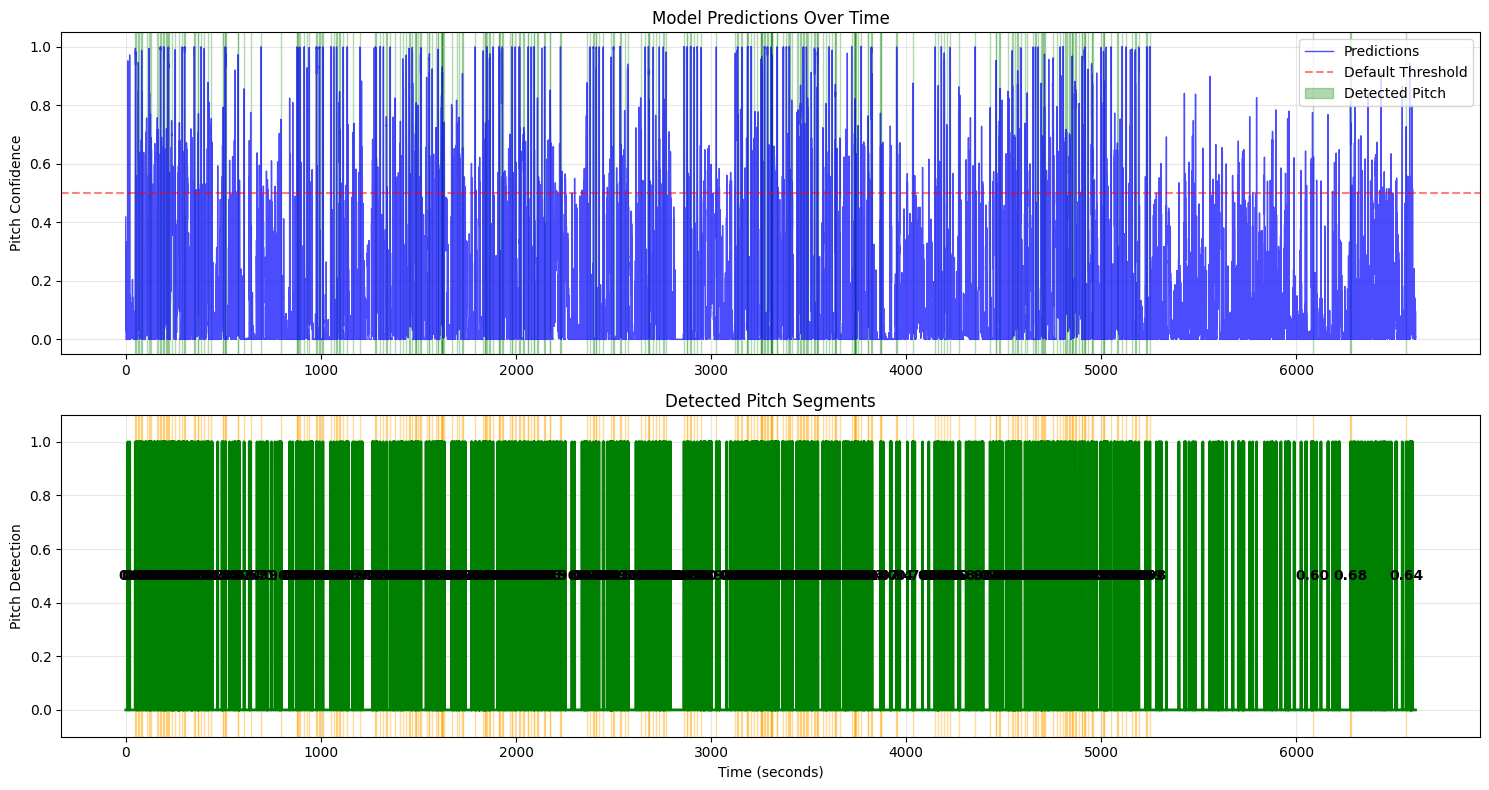

In [20]:
# Example: Generate video clips with pose overlay for detected pitches
if 'loaded_model' in locals():
    model_to_use = loaded_model
elif 'model' in locals():
    model_to_use = model
else:
    print("❌ No trained model available. Train a model first or load from checkpoint.")
    model_to_use = None

if model_to_use is not None:
    # You'll need to provide the path to your original video file
    # Update this path to point to your actual video file
    original_video_path = "../Data/training/tennessee_alabama_sr_gm1.mp4"  # Update this path!
    
    print("🎬 Generating pitch detection video clips...")
    print("Note: Make sure the original_video_path points to your actual video file")
    
    # Check if video file exists
    if os.path.exists(original_video_path):
        # Generate clips with pose overlay
        generate_pitch_video_clips(
            model=model_to_use,
            pose_file=pose_files[0],
            video_file=video_files[0], 
            original_video_path=original_video_path,
            output_dir="./pitch_clips",
            fps=30,
            threshold=0.9,  # Lower threshold to catch more potential pitches
            padding_seconds=3,  # Add 1.5s before and after each pitch
            max_clips=15  # Generate up to 3 clips
        )
        
        # Also create a prediction visualization plot
        if 'results' in locals() and 'frame_predictions' in results:
            create_prediction_visualization(
                results['frame_predictions'], 
                results['segments'], 
                fps=30,
                save_path="./pitch_clips/prediction_visualization.png"
            )
    else:
        print(f"⚠️ Video file not found: {original_video_path}")
        print("Please update the 'original_video_path' variable to point to your video file.")
        print("\nAlternatively, you can generate just the prediction visualization:")
        
        # Generate prediction visualization without video clips
        if 'results' in locals() and 'frame_predictions' in results:
            create_prediction_visualization(
                results['frame_predictions'], 
                results['segments'], 
                fps=30,
                save_path="./prediction_visualization.png"
            )
else:
    print("❌ No model available for video generation.")
    print("Please train a model first or load from checkpoint.")